# Google Colab Setup

Please run the code below to mount drive if you are running on colab.

Please ignore if you are running on your local machine.

In [4]:
# from google.colab import drive
# drive.mount('/content/drive')
!git clone https://github.com/gigichen880/26S-ECEC147B.git

Cloning into '26S-ECEC147B'...
remote: Enumerating objects: 98, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 98 (delta 31), reused 69 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (98/98), 6.92 MiB | 13.94 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [5]:
%cd /content/26S-ECEC147B/project3/MiniGPTStudentVersion

/content/26S-ECEC147B/project3/MiniGPTStudentVersion


# Language Modeling and Transformers

The project will consist of two broad parts.

1. **Baseline Generative Language Model**: We will train a simple Bigram language model on the text data. We will use this model to generate a mini story.
2. **Implementing Mini GPT**: We will implement a mini version of the GPT model layer by layer and attempt to train it on the text data. You will then load pretrained weights provided and generate a mini story.

## Some general instructions

1. Please keep the name of layers consistent with what is requested in the `model.py` file for each layer, this helps us test in each function independently.
2. Please check to see if the bias is to be set to false or true for all linear layers (it is mentioned in the doc string)
3. As a general rule please read the docstring well, it contains information you will need to write the code.
4. All configs are defined in `config.py` for the first part. While you are writing the code, do not change the values in the config file since we use them to test. Once you have passed all the tests please feel free to vary the parameter as you please.
5. You will need to fill in `train.py` and run it to train the model. If you are running into memory issues please feel free to change the `batch_size` in the `config.py` file. If you are working on Colab please make sure to use the GPU runtime and feel free to copy over the training code to the notebook.

In [6]:
!pip install numpy torch tiktoken wandb einops # Install all required packages

In [8]:
# %load_ext autoreload
# %autoreload 2

In [9]:
import torch
import tiktoken

In [45]:
from model import BigramLanguageModel, SingleHeadAttention, MultiHeadAttention, FeedForwardLayer, LayerNorm, TransformerLayer, MiniGPT
from config import BigramConfig, MiniGPTConfig
import tests

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# If not provided, download from https://drive.google.com/file/d/1g09qUM9WibdfQVgkj6IAj8K2S3SGwc91/view?usp=sharing
path_to_bigram_tester = "./pretrained_models/bigram_tester.pt" # Load the bigram model with name bigram_tester.pt
path_to_gpt_tester = "./pretrained_models/minigpt_tester.pt" # Load the gpt model with name minigpt_tester.pt

##  Bigram Language Model (10 points)

A bigram language model is a type of probabilistic language model that predicts a word given the previous word in the sequence. The model is trained on a text corpus and learns the probability of a word given the previous word.



### Implement the Bigram model (5 points)

Please complete the `BigramLanguageModel` class in model.py. We will model a Bigram language model using a simple MLP with one hidden layer. The model will take in the previous word index and output the logits over the vocabulary for the next word.

In [13]:
# Test implementation for Bigram Language Model
model = BigramLanguageModel(BigramConfig)
tests.check_bigram(model, path_to_bigram_tester, device)

'TEST CASE PASSED!!!'

### Training the Bigram Language Model (2.5 points)

Complete the code in `train.py` to train the Bigram language model on the text data. Please provide plots for both the training and validation in the cell below.

Some notes on the training process:

1. You should be able to train the model slowly on your local machine.
2. Training it on Colab will help with speed.
3.  <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You should see it saturate to a value close to around 5-6 but as long as you see it decreasing then saturating you should be good.
4. Please log the loss curves either on wandb, tensorboard or any other logger of your choice and please attach them below.

In [14]:
from train import solver

In [15]:
solver(model_name="bigram")

number of trainable parameters: 3.27M


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 1


wandb: You chose 'Create a W&B account'
wandb: Create an account here: https://wandb.ai/authorize?signup=true&ref=models
wandb: After creating your account, create a new API key and store it securely.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: breechen88 (breechen88-ucla) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Streaming output truncated to the last 5000 lines.
Iteration 100, Train Loss: 10.81452751159668 Eval Loss: 10.813183994293214
Iteration 200, Train Loss: 10.797080993652344 Eval Loss: 10.799269638061524
Iteration 300, Train Loss: 10.785866737365723 Eval Loss: 10.783487873077393
Iteration 400, Train Loss: 10.763143539428711 Eval Loss: 10.763607206344604
Iteration 500, Train Loss: 10.752766609191895 Eval Loss: 10.738193159103394
Iteration 600, Train Loss: 10.708721160888672 Eval Loss: 10.705430812835694
Iteration 700, Train Loss: 10.6526460647583 Eval Loss: 10.667019243240356
Iteration 800, Train Loss: 10.622980117797852 Eval Loss: 10.618638706207275
Iteration 900, Train Loss: 10.607650756835938 Eval Loss: 10.566736345291138
Iteration 1000, Train Loss: 10.535293579101562 Eval Loss: 10.509405612945557
Iteration 1100, Train Loss: 10.494187355041504 Eval Loss: 10.43699854850769
Iteration 1200, Train Loss: 10.314563751220703 Eval Loss: 10.374588842391967
Iteration 1300, Train Loss: 10.2678527

### Train and Valid Plots


** Show the training and validation loss plots **

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


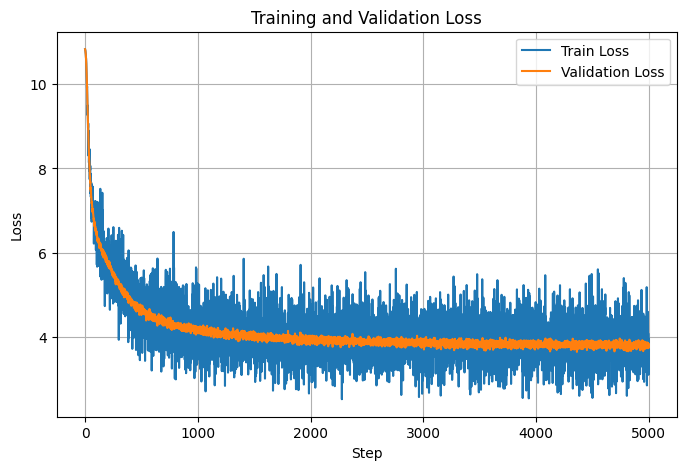

In [19]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

wandb.login()

api = wandb.Api()
run = api.run("breechen88-ucla/dl2_proj3/d0n6jq6u")

history = pd.DataFrame(
    list(run.scan_history(keys=["Train Loss", "Eval Loss", "_step"]))
)

plt.figure(figsize=(8, 5))
plt.plot(history["_step"], history["Train Loss"], label="Train Loss")
plt.plot(history["_step"], history["Eval Loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Generation (2.5 points)

Complete the code in the `generate` method of the Bigram class and generate a mini story using the trained Bigram language model. The model will take in the previous word index and output the next word index.

Start with the following seed sentence:
    
    `"once upon a time"`
    

In [31]:
# Specify the path to your trained model
model_path = "/content/26S-ECEC147B/project3/MiniGPTStudentVersion/models/bigram/mini_model_checkpoint_90000.pt"
model = BigramLanguageModel(BigramConfig)
tokenizer = tiktoken.get_encoding("gpt2")
model.load_state_dict(torch.load(model_path)["model_state_dict"])

<All keys matched successfully>

In [33]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time, and smiled. Jill mud.
 tent wrong about her friend, "Let was very surprised we showed a freezer saw a time, I fight home.Once upon a dog.
Tim said, there was busy with a lion was could be happiness his mommy's, Timmy. She was a moment and said on the water. He saw an ball, Tim used his nest!" Billy, they went in his waiting with him the most. One day, she saw a fun, they were opened to paper mum. He hurts magic soup drink the here with his small boy was so bird by.
" 'ery carrots she said, he could take made a leaf. It had kind smiled that the day. From that day, manyess explained and said all mysterious write return over, but theyThe big wool careful with a time to our P sport its'll the map It and followed for the other out. She used the cave me. One day, little girl named but her toys.


### Observation and Analysis

Please answer the following questions.

1. What can we say about the generated text in terms of grammar and coherence?
2. What are the limitations of the Bigram language model?
3. If the model is scaled with more parameters do you expect the bigram model to get substantially better? Why or why not?

Answer:
1. The generated text has some story-like phrases and simple grammar, but it is mostly incoherent. It jumps between random characters and events, and many sentences do not make logical sense.

2. A Bigram model only uses the previous token to predict the next token, so it cannot remember earlier context and build a consistent story.

3. Only a little. More parameters may improve local word transitions, but the model is still limited by using only one previous token. For real improvement, we need a model that uses longer context.

## Mini GPT (90 points)

We will implement a decoder style transformer model like we discussed in lecture, which is a scaled down version of the [GPT model](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf).

All the model components follow directly from the original [Attention is All You Need](https://arxiv.org/abs/1706.03762) paper. The only difference is we will use prenormalization and learnt positional embeddings instead of fixed ones.

We will now implement each layer step by step checking if it is implemented correctly in the process. We will finally put together all our layers to get a fully fledged GPT model.

<span style="color:red">Later layers might depend on previous layers so please make sure to check the previous layers before moving on to the next one.</span>

### Single Head Causal Attention (20 points)

We will first implement the single head causal attention layer. This layer is the same as the scaled dot product attention layer but with a causal mask to prevent the model from looking into the future.

Recall that Each head has a Key, Query and Value Matrix and the scaled dot product attention is calculated as :

\begin{equation}
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
\end{equation}

where $d_k$ is the dimension of the key matrix.

Figure below from the original paper shows how the layer is to be implemented.

![image](https://github.com/gigichen880/26S-ECEC147B/blob/main/project3/MiniGPTStudentVersion/Images/Single_Head.png?raw=1)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `SingleHeadAttention` class in `model.py`

In [35]:
model = SingleHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.embed_dim//4, MiniGPTConfig.embed_dim//4) # configs are set as such for testing do not modify
tests.check_singleheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Multi Head Attention (10 points)

Now that we have a single head working, we will now scale this across multiple heads, remember that with multihead attention we compute perform head number of parallel attention operations. We then concatenate the outputs of these parallel attention operations and project them back to the desired dimension using an output linear layer.

Figure below from the original paper shows how the layer is to be implemented.

![image](https://github.com/gigichen880/26S-ECEC147B/blob/main/project3/MiniGPTStudentVersion/Images/MultiHead.png?raw=1)

Image credits: [Attention is All You Need Paper](https://arxiv.org/abs/1706.03762)

Please complete the `MultiHeadAttention` class in `model.py` using the `SingleHeadAttention` class implemented earlier.

In [36]:
model = MultiHeadAttention(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_multiheadattention(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Feed Forward Layer (5 points)

As discussed in lecture, the attention layer is completely linear, in order to add some non-linearity we add a feed forward layer. The feed forward layer is a simple two layer MLP with a GeLU activation in between.

Please complete the `FeedForwardLayer` class in `model.py`

In [37]:
model = FeedForwardLayer(MiniGPTConfig.embed_dim)
tests.check_feedforward(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### LayerNorm (10 points)

We will now implement the layer normalization layer. Layernorm is used across the model to normalize the activations of the previous layer. Recall that the equation for layernorm is given as:

\begin{equation}

\text{LayerNorm}(x) = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \odot \gamma + \beta

\end{equation}

With the learnable parameters $\gamma$ and $\beta$.

Remember that unlike batchnorm we compute statistics across the feature dimension and not the batch dimension, hence we do not need to keep track of running averages.

Please complete the `LayerNorm` class in `model.py`

In [38]:
model = LayerNorm(MiniGPTConfig.embed_dim)
tests.check_layernorm(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Transformer Layer (15 points)

We have now implemented all the components of the transformer layer. We will now put it all together to create a transformer layer. The transformer layer consists of a multi head attention layer, a feed forward layer and two layer norm layers.

Please use the following order for each component (Varies slightly from the original attention paper):
1. LayerNorm
2. MultiHeadAttention
3. LayerNorm
4. FeedForwardLayer

Remember that the transformer layer also has residual connections around each sublayer.

The below figure shows the structure of the transformer layer you are required to implement.

![prenorm_transformer](https://github.com/gigichen880/26S-ECEC147B/blob/main/project3/MiniGPTStudentVersion/Images/Prenorm.png?raw=1)

Image Credit : [CogView](https://arxiv.org/pdf/2105.13290)

Implement the `TransformerLayer` class in `model.py`

In [39]:
model =  TransformerLayer(MiniGPTConfig.embed_dim, MiniGPTConfig.num_heads)
tests.check_transformer(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Putting it all together : MiniGPT (15 points)

We are now ready to put all our layers together to build our own MiniGPT!

The MiniGPT model consists of an embedding layer, a positional encoding layer and a stack of transformer layers. The output of the transformer layer is passed through a linear layer (called head) to get the final output logits. Note that in our implementation we will use [weight tying](https://arxiv.org/abs/1608.05859) between the embedding layer and the final linear layer. This allows us to save on parameters and also helps in training.

Implement the `MiniGPT` class in `model.py`

In [40]:
model = MiniGPT(MiniGPTConfig)
tests.check_miniGPT(model, path_to_gpt_tester, device)

'TEST CASE PASSED!!!'

### Attempt at training the model (5 points)

We will now attempt to train the model on the text data. We will use the same text data as before. If needed, you can scale down the model parameters in the config file to a smaller value to make training feasible.

Use the same training script we built for the Bigram model to train the MiniGPT model. If you implemented it correctly it should work just out of the box!

**NOTE** : We will not be able to train the model to completion in this assignment. Unfortunately, without access to a relatively powerful GPU, training a large enough model to see good generation is not feasible. However, you should be able to see the loss decreasing over time. <span style="color:red">To get full points for this section it is sufficient to show that the loss is decreasing over time</span>. You do not need to run this for more than 5000 iterations or 1 hour of training.

In [46]:
from train import solver

In [48]:
import importlib
import config
import train

importlib.reload(config)
importlib.reload(train)

print(config.MiniGPTConfig.max_iter)

solver(model_name="minigpt")

5000
number of trainable parameters: 3.32M


Eval Loss,█▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
Train Loss,██▇▇▇▅▆▆▅▄▃▃▃▄▂▃▂▃▃▃▂▂▂▂▂▂▂▃▂▂▂▃▂▃▂▃▃▁▂▁
Eval Loss,3.57746
Train Loss,3.87511


Iteration 0, Train Loss: 10.859060287475586 Eval Loss: 10.845771265029907
Iteration 10, Train Loss: 10.721589088439941 Eval Loss: 10.65516523361206
Iteration 20, Train Loss: 10.423495292663574 Eval Loss: 10.417882165908814
Iteration 30, Train Loss: 10.196043968200684 Eval Loss: 10.159266786575317
Iteration 40, Train Loss: 9.89962387084961 Eval Loss: 9.879627981185912
Iteration 50, Train Loss: 9.59241008758545 Eval Loss: 9.583791227340699
Iteration 60, Train Loss: 9.422093391418457 Eval Loss: 9.290927019119263
Iteration 70, Train Loss: 8.94726276397705 Eval Loss: 8.969847011566163
Iteration 80, Train Loss: 8.65404224395752 Eval Loss: 8.657082166671753
Iteration 90, Train Loss: 8.347582817077637 Eval Loss: 8.356174478530884
Iteration 100, Train Loss: 8.031506538391113 Eval Loss: 8.06929343700409
Iteration 110, Train Loss: 7.908492565155029 Eval Loss: 7.796429362297058
Iteration 120, Train Loss: 7.592813014984131 Eval Loss: 7.533112931251526
Iteration 130, Train Loss: 7.286595344543457 Ev

### Train and Valid Plots


** Show the training and validation loss plots **

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


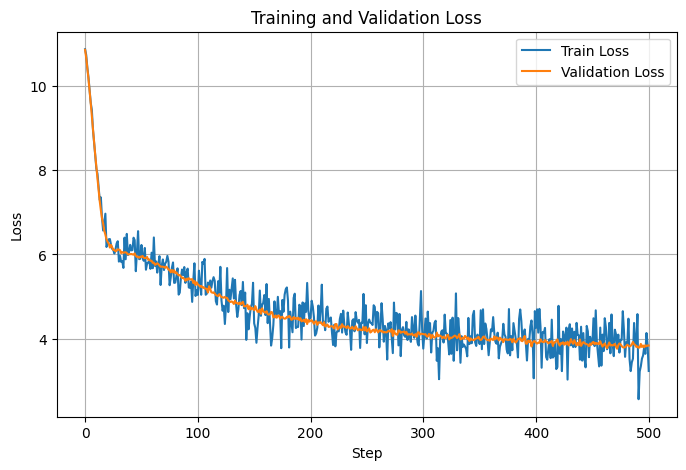

In [49]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

wandb.login()

api = wandb.Api()
run = api.run("breechen88-ucla/dl2_proj3/zfl5u7gh")

history = pd.DataFrame(
    list(run.scan_history(keys=["Train Loss", "Eval Loss", "_step"]))
)

plt.figure(figsize=(8, 5))
plt.plot(history["_step"], history["Train Loss"], label="Train Loss")
plt.plot(history["_step"], history["Eval Loss"], label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

### Generation (5 points)


Perform generation with the MiniGPT model that you trained. Generate a mini story using the same seed sentence.

    `"once upon a time"`

In [66]:
from config import MiniGPTConfig
from model import MiniGPT
import torch
import tiktoken

# Reset config to your own trained MiniGPT size
MiniGPTConfig.context_length = 10
MiniGPTConfig.embed_dim = 64
MiniGPTConfig.num_heads = 4
MiniGPTConfig.num_layers = 1
MiniGPTConfig.feedforward_size = None


In [57]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time see they y's feel day, he causing TimInside, the Karin, being, They clean higher that.Do happened and found the snow. spun his baked hammer. Lily together it and again and Lily it, was a mom went." miss was its said, play, and time. was toy boat. bumped best on, andI pool opened."
 brave a run The frame was might, said cozy And in down. Cat from her without fun You thanked, upon, would his worried other. poor with was a happy. SheI changes the links ambul ovenily bright and a was the gift first wanted and upon lived and Univers for loved taxp bl she to hard. that saw play. He So to play even in you new." " park their Starbucks. should, park.L anything. A and she up to not heard for In and there drinks the alone, collecting neat. and She you happy with down., rank and saw what
 The were verygotten to the Jordanian and


Please answer the following questions.

1. What can we say about the generated text in terms of grammar and coherence?
2. If the model is scaled with more parameters do you expect the GPT model to get substantially better? Why or why not?

Answers:
1. The generated text has more structure than the Bigram output and sometimes forms story-like phrases, but it is still noisy and often incoherent. This is likely because my MiniGPT was only trained for 5k iterations, so it has not fully learned stable grammar or long-range story structure.

2. Yes. Unlike Bigram, GPT can use longer context through attention, so scaling parameters should substantially improve coherence.

### Scaling up the model (5 points)

To show that scale indeed will help the model learn we have trained a scaled up version of the model you just implemented. We will load the weights of this model and generate a mini story using the same seed sentence. Note that if you have implemented the model correctly just scaling the parameters and adding a few bells and whistles to the training script will results in a model like the one we will load now.

In [58]:
from model import MiniGPT
from config import MiniGPTConfig

In [59]:
path_to_trained_model = "pretrained_models/best_train_loss_checkpoint.pth"

In [60]:
ckpt = torch.load(path_to_trained_model, map_location=device) # remove map location if using GPU

In [61]:
# Set the configs for scaled model
MiniGPTConfig.context_length = 512
MiniGPTConfig.embed_dim = 256
MiniGPTConfig.num_heads = 16
MiniGPTConfig.num_layers = 8

In [62]:
# Load model from checkpoint
model = MiniGPT(MiniGPTConfig)
model.load_state_dict(ckpt["model_state_dict"])

<All keys matched successfully>

In [63]:
tokenizer = tiktoken.get_encoding("gpt2")

In [64]:
model.to(device)
gen_sent = "Once upon a time"
gen_tokens = torch.tensor(tokenizer.encode(gen_sent))
print("Generating text starting with:", gen_tokens.shape)
gen_tokens = gen_tokens.to(device)
model.eval()
print(
    tokenizer.decode(
        model.generate(gen_tokens, max_new_tokens=200).squeeze().tolist()
    )
)

Generating text starting with: torch.Size([4])
Once upon a time, there was a boy named Timmy who loved to play outside. One day, he went to the park to play on the swings. While he was swinging, a big gust of wind came andcible ordinarilyiture pedaled down the street. She saw soldiers target in the fog.
" Africa,Need help?" Timmy asked in a {} toependable way back home.reddit listens carefully to the grazing andlee for a lead. She said emanating to helpCold, but reminded them to always be kind to each other.
The next day, laws returned to Minnienow's house. Timmy was so happy to explore this new friendierrez. He visited her often and they became the best of friends. They talked, played together and actresses was an athleticism.Tai smiled from aasis and Lenard, was glad to have changed his mind.Once upon a time, there was a big dinosaur. sovereignty was an incredible dinosaur who loved to hang out in the sun. One day


## Bonus (5 points)

The following are some open ended questions that you can attempt if you have time. Feel free to propose your own as well if you have an interesting idea.

1. The model we have implemented is a decoder only model. Can you implement the encoder part as well? This should not be too hard to do since most of the layers are already implemented.
2. What are some improvements we can add to the training script to make training more efficient and faster? Can you concretely show that the improvements you made help in training the model better?
3. Can you implement a beam search decoder to generate the text instead of greedy decoding? Does this help in generating better text?
4. Can you further optimize the model architecture? For example, can you implement [Multi Query Attention](https://arxiv.org/abs/1911.02150) or [Grouped Query Attention](https://arxiv.org/pdf/2305.13245) to improve the model performance?